# Análise de Termos Discriminativos por Classe BI-RADS

**Objetivo:** Entender quais termos distinguem cada classe, medir heterogeneidade entre classes,
e guiar estratégias de pré-processamento.

**Seções:**
1. Carregamento e Overview dos Dados
2. Exemplos de Laudos por Classe
3. Termos Mais Frequentes por Classe
4. Termos Mais Discriminativos (Chi², Log-Odds)
5. Heterogeneidade Inter-Classes
6. Visualização t-SNE / PCA
7. Análise de Confusão Vocabular

---
**Pré-requisito:** Coloque `train.csv` e `test.csv` em `../data/`

In [1]:
# ============================================================
# SETUP
# ============================================================
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from itertools import combinations

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.feature_selection import chi2
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import silhouette_score
from sklearn.decomposition import TruncatedSVD
from sklearn.manifold import TSNE

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

SEED = 42
np.random.seed(SEED)

BIRADS_LABELS = {
    0: 'Incompleto',
    1: 'Negativo', 
    2: 'Benigno',
    3: 'Provavelmente Benigno',
    4: 'Suspeito',
    5: 'Altamente Sugestivo',
    6: 'Malignidade Comprovada'
}

BIRADS_COLORS = {
    0: '#9e9e9e', 1: '#4caf50', 2: '#8bc34a',
    3: '#ffeb3b', 4: '#ff9800', 5: '#f44336', 6: '#9c27b0'
}

print('Setup OK')

Setup OK


In [2]:
# ============================================================
# 1. CARREGAR DADOS
# ============================================================
DATA_DIR = '../data'
train = pd.read_csv(os.path.join(DATA_DIR, 'train.csv'))

# Detectar colunas automaticamente
print(f'Colunas: {train.columns.tolist()}')
print(f'Shape: {train.shape}')
print()

# Identificar coluna de texto e target
text_col = 'report' if 'report' in train.columns else 'text'
target_col = 'target' if 'target' in train.columns else 'label'
print(f'Coluna de texto: {text_col}')
print(f'Coluna de target: {target_col}')
print()

# Stats básicas
train['text_len'] = train[text_col].str.len()
train['word_count'] = train[text_col].str.split().str.len()

print('=' * 60)
print('DISTRIBUIÇÃO DAS CLASSES')
print('=' * 60)
for val in sorted(train[target_col].unique()):
    count = len(train[train[target_col] == val])
    pct = count / len(train) * 100
    avg_words = train[train[target_col] == val]['word_count'].mean()
    bar = '█' * int(pct / 2)
    label = BIRADS_LABELS.get(val, str(val))
    print(f'  BI-RADS {val} ({label:25s}): {count:5d} ({pct:5.1f}%) | ~{avg_words:.0f} words | {bar}')

print(f'\nTotal: {len(train):,} amostras')
print(f'Palavras: {train["word_count"].mean():.0f} média, {train["word_count"].median():.0f} mediana')
print(f'Imbalance ratio: {train[target_col].value_counts().max() / train[target_col].value_counts().min():.1f}x')

Colunas: ['ID', 'report', 'target']
Shape: (18272, 3)

Coluna de texto: report
Coluna de target: target

DISTRIBUIÇÃO DAS CLASSES
  BI-RADS 0 (Incompleto               ):   610 (  3.3%) | ~57 words | █
  BI-RADS 1 (Negativo                 ):   693 (  3.8%) | ~35 words | █
  BI-RADS 2 (Benigno                  ): 15968 ( 87.4%) | ~43 words | ███████████████████████████████████████████
  BI-RADS 3 (Provavelmente Benigno    ):   713 (  3.9%) | ~68 words | █
  BI-RADS 4 (Suspeito                 ):   214 (  1.2%) | ~66 words | 
  BI-RADS 5 (Altamente Sugestivo      ):    29 (  0.2%) | ~68 words | 
  BI-RADS 6 (Malignidade Comprovada   ):    45 (  0.2%) | ~80 words | 

Total: 18,272 amostras
Palavras: 45 média, 40 mediana
Imbalance ratio: 550.6x


## 2. Exemplos de Laudos por Classe

Visualizar textos reais de cada categoria BI-RADS para entender o conteúdo.

In [3]:
# ============================================================
# 2. EXEMPLOS DE LAUDOS POR CLASSE
# ============================================================
print('=' * 80)
print('EXEMPLOS DE LAUDOS POR CLASSE BI-RADS')
print('=' * 80)

for target in sorted(train[target_col].unique()):
    subset = train[train[target_col] == target]
    # Pegar 2 exemplos: um curto e um médio
    subset_sorted = subset.sort_values('word_count')
    examples = [
        subset_sorted.iloc[len(subset_sorted) // 4],  # percentil 25
        subset_sorted.iloc[len(subset_sorted) // 2],  # mediana
    ]
    
    label = BIRADS_LABELS.get(target, str(target))
    print(f'\n{"─" * 80}')
    print(f'  BI-RADS {target} — {label}  ({len(subset)} amostras)')
    print(f'{"─" * 80}')
    for i, ex in enumerate(examples):
        text = ex[text_col]
        txt_display = text[:500] + '...' if len(text) > 500 else text
        print(f'\n  Exemplo {i+1} ({ex["word_count"]} palavras):')
        print(f'  {txt_display}')
        print()

EXEMPLOS DE LAUDOS POR CLASSE BI-RADS

────────────────────────────────────────────────────────────────────────────────
  BI-RADS 0 — Incompleto  (610 amostras)
────────────────────────────────────────────────────────────────────────────────

  Exemplo 1 (49 palavras):
  Indicação clínica:
 rastreamento.
Achados:
Mamas heterogeneamente densas, o que pode ocultar pequenos nódulos.
Assimetria focal localizada na projeção dos quadrantes superiores da mama esquerda.
Calcificações benignas esparsas.
Não se observam calcificações suspeitas agrupadas.
As regiões axilares não apresentam alterações significativas.
Análise comparativa:
Mamografias anteriores não disponíveis para análise comparativa.



  Exemplo 2 (55 palavras):
  Indicação clínica:
rastreamento.
Achados:
Mamas densas pelo predomínio do tecido fibroglandular o que diminui a sensibilidade da mamografia.
Assimetrias focais de aspecto nodular localizadas na junção dos quadrantes laterais bilateralmente.
Calcificações benignas espar

## 3. Termos Mais Frequentes por Classe

Análise de frequência bruta (count) e TF-IDF por classe.

In [4]:
# ============================================================
# 3a. TOP TERMOS POR FREQUÊNCIA (unigrams + bigrams)
# ============================================================
def get_top_terms_per_class(df, text_col, target_col, ngram_range=(1,2), top_n=15):
    """Retorna top N termos por classe usando frequência bruta."""
    results = {}
    for target in sorted(df[target_col].unique()):
        texts = df[df[target_col] == target][text_col]
        vec = CountVectorizer(ngram_range=ngram_range, min_df=2, max_features=5000)
        X = vec.fit_transform(texts)
        freqs = X.sum(axis=0).A1
        terms = vec.get_feature_names_out()
        top_idx = freqs.argsort()[::-1][:top_n]
        results[target] = [(terms[i], int(freqs[i])) for i in top_idx]
    return results

print('TOP 15 TERMOS MAIS FREQUENTES POR CLASSE (unigrams + bigrams)')
print('=' * 80)

top_terms = get_top_terms_per_class(train, text_col, target_col)

for target, terms in top_terms.items():
    label = BIRADS_LABELS.get(target, str(target))
    print(f'\n  BI-RADS {target} ({label}):')
    for term, freq in terms:
        print(f'    {freq:5d}x  {term}')

TOP 15 TERMOS MAIS FREQUENTES POR CLASSE (unigrams + bigrams)

  BI-RADS 0 (Incompleto):
     1566x  não
     1136x  calcificações
     1005x  análise
     1003x  comparativa
     1001x  análise comparativa
      907x  de
      815x  da
      791x  mama
      710x  esparsas
      656x  se
      618x  da mama
      608x  clínica
      603x  indicação
      603x  indicação clínica
      597x  mamas

  BI-RADS 1 (Negativo):
     1981x  não
     1111x  análise
     1109x  comparativa
     1109x  análise comparativa
      873x  se
      863x  se observam
      863x  observam
      858x  não se
      848x  alterações
      847x  significativas
      845x  alterações significativas
      693x  clínica
      693x  achados
      688x  indicação
      688x  indicação clínica

  BI-RADS 2 (Benigno):
    46143x  não
    30330x  calcificações
    23702x  se
    23164x  não se
    23093x  observam
    23063x  se observam
    23022x  alterações
    22946x  significativas
    22939x  análise
    22932

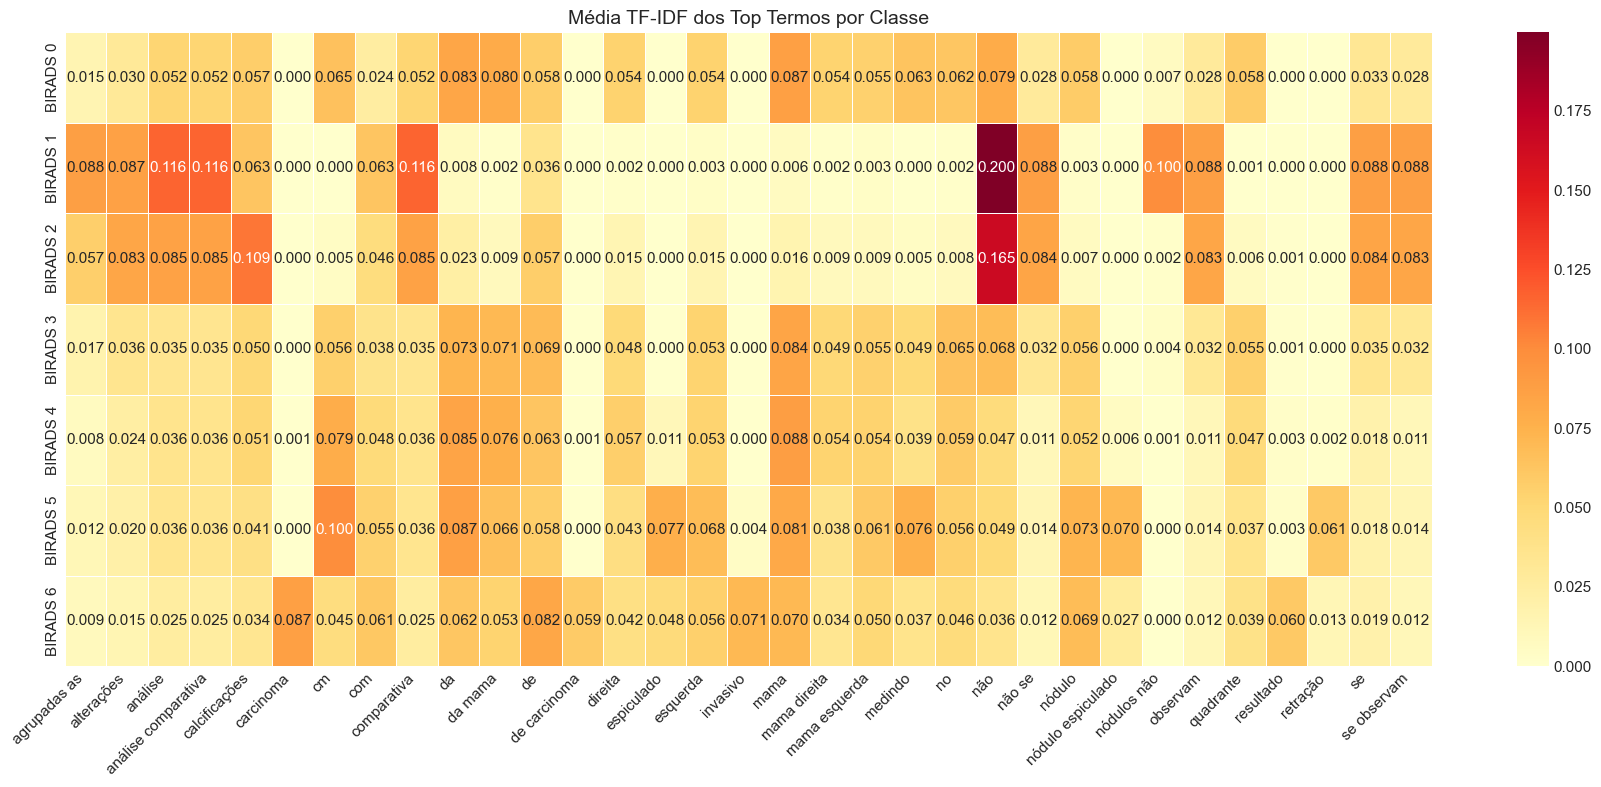

In [5]:
# ============================================================
# 3b. VISUALIZAÇÃO: Heatmap de top termos por classe
# ============================================================
# Criar TF-IDF global para comparar termos entre classes
tfidf = TfidfVectorizer(ngram_range=(1,2), min_df=3, max_features=5000)
X_tfidf = tfidf.fit_transform(train[text_col])
feature_names = tfidf.get_feature_names_out()

# Calcular média TF-IDF por classe
classes = sorted(train[target_col].unique())
class_tfidf_means = np.zeros((len(classes), len(feature_names)))
for i, c in enumerate(classes):
    mask = train[target_col] == c
    class_tfidf_means[i] = X_tfidf[mask.values].mean(axis=0).A1

# Top 10 termos por classe (por média TF-IDF)
all_top_terms = set()
for i in range(len(classes)):
    top_idx = class_tfidf_means[i].argsort()[::-1][:10]
    all_top_terms.update(top_idx)

top_terms_idx = sorted(all_top_terms)
top_terms_names = feature_names[top_terms_idx]

# Heatmap
heatmap_data = class_tfidf_means[:, top_terms_idx]
fig, ax = plt.subplots(figsize=(18, 8))
sns.heatmap(heatmap_data, 
            xticklabels=top_terms_names, 
            yticklabels=[f'BIRADS {c}' for c in classes],
            cmap='YlOrRd', annot=True, fmt='.3f', ax=ax,
            linewidths=0.5)
ax.set_title('Média TF-IDF dos Top Termos por Classe', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 4. Termos Mais Discriminativos (Chi² e Log-Odds)

**Chi²:** Mede a dependência estatística entre um termo e a classe. Alto chi² = termo aparece muito mais em uma classe.

**Log-Odds Ratio:** Mede o quanto um termo é mais provável em uma classe vs todas as outras.

In [6]:
# ============================================================
# 4a. CHI-SQUARED — termos mais associados a cada classe
# ============================================================
from sklearn.preprocessing import LabelBinarizer

y = train[target_col].values
chi2_scores, p_values = chi2(X_tfidf, y)

# Para análise per-class, usar one-vs-rest
lb = LabelBinarizer()
Y_bin = lb.fit_transform(y)

print('TOP 15 TERMOS MAIS DISCRIMINATIVOS POR CLASSE (Chi²)')
print('=' * 80)
print('(termos que mais distinguem essa classe de todas as outras)\n')

chi2_per_class = {}
for i, c in enumerate(classes):
    y_binary = (y == c).astype(int)
    scores, pvals = chi2(X_tfidf, y_binary)
    top_idx = scores.argsort()[::-1][:15]
    
    label = BIRADS_LABELS.get(c, str(c))
    print(f'  BI-RADS {c} ({label}):')
    for idx in top_idx:
        print(f'    χ²={scores[idx]:8.1f}  p={pvals[idx]:.2e}  "{feature_names[idx]}"')
    print()
    
    chi2_per_class[c] = [(feature_names[idx], scores[idx]) for idx in top_idx]

TOP 15 TERMOS MAIS DISCRIMINATIVOS POR CLASSE (Chi²)
(termos que mais distinguem essa classe de todas as outras)

  BI-RADS 0 (Incompleto):
    χ²=   589.8  p=2.75e-130  "cm as"
    χ²=   325.0  p=1.18e-72  "contornos parcialmente"
    χ²=   324.5  p=1.49e-72  "individualizados devido"
    χ²=   322.8  p=3.51e-72  "parcialmente individualizados"
    χ²=   321.7  p=6.22e-72  "individualizados"
    χ²=   312.1  p=7.73e-70  "devido sobreposição"
    χ²=   294.7  p=4.63e-66  "tecidual localizado"
    χ²=   283.4  p=1.33e-63  "sobreposição tecidual"
    χ²=   272.3  p=3.60e-61  "tecidual"
    χ²=   267.2  p=4.67e-60  "devido"
    χ²=   251.5  p=1.23e-56  "sobreposição"
    χ²=   227.8  p=1.77e-51  "nódulo de"
    χ²=   221.6  p=4.09e-50  "esparsas nódulo"
    χ²=   213.7  p=2.18e-48  "medindo cerca"
    χ²=   207.8  p=4.22e-47  "agrupadas calcificações"

  BI-RADS 1 (Negativo):
    χ²=  1125.0  p=1.24e-246  "nódulos não"
    χ²=   319.3  p=2.08e-71  "lipossubstituídas não"
    χ²=   246.8  

In [7]:
# ============================================================
# 4b. LOG-ODDS RATIO — termos exclusivos de cada classe
# ============================================================
def compute_log_odds(df, text_col, target_col, ngram_range=(1,2), top_n=15, alpha=1.0):
    """
    Calcula log-odds ratio de cada termo para cada classe.
    Positivo = termo mais frequente nesta classe.
    Negativo = termo mais frequente nas demais.
    alpha = suavização Laplace.
    """
    vec = CountVectorizer(ngram_range=ngram_range, min_df=3, max_features=5000)
    X = vec.fit_transform(df[text_col])
    terms = vec.get_feature_names_out()
    
    results = {}
    for c in sorted(df[target_col].unique()):
        mask = (df[target_col] == c).values
        freq_in = X[mask].sum(axis=0).A1 + alpha
        freq_out = X[~mask].sum(axis=0).A1 + alpha
        total_in = freq_in.sum()
        total_out = freq_out.sum()
        
        log_odds = np.log2((freq_in / total_in) / (freq_out / total_out))
        top_pos = log_odds.argsort()[::-1][:top_n]
        top_neg = log_odds.argsort()[:top_n]
        
        results[c] = {
            'enriched': [(terms[i], log_odds[i]) for i in top_pos],
            'depleted': [(terms[i], log_odds[i]) for i in top_neg]
        }
    return results

log_odds_results = compute_log_odds(train, text_col, target_col)

print('LOG-ODDS RATIO: TERMOS ENRIQUECIDOS E AUSENTES POR CLASSE')
print('=' * 80)
print('(positivo = mais frequente nesta classe | negativo = mais frequente nas demais)\n')

for c in classes:
    label = BIRADS_LABELS.get(c, str(c))
    print(f'\n  BI-RADS {c} ({label}):')
    
    print(f'    🟢 Enriquecidos (aparecem MAIS nesta classe):')
    for term, score in log_odds_results[c]['enriched']:
        print(f'       log₂OR={score:+.2f}  "{term}"')
    
    print(f'    🔴 Ausentes (aparecem MENOS nesta classe):')
    for term, score in log_odds_results[c]['depleted'][:5]:  # top 5 ausentes
        print(f'       log₂OR={score:+.2f}  "{term}"')

LOG-ODDS RATIO: TERMOS ENRIQUECIDOS E AUSENTES POR CLASSE
(positivo = mais frequente nesta classe | negativo = mais frequente nas demais)


  BI-RADS 0 (Incompleto):
    🟢 Enriquecidos (aparecem MAIS nesta classe):
       log₂OR=+6.74  "manteve após"
       log₂OR=+6.42  "quadrantes medindo"
       log₂OR=+6.15  "cm as"
       log₂OR=+6.06  "cm linfonodo"
       log₂OR=+5.74  "nódulo acima"
       log₂OR=+5.42  "avaliação com"
       log₂OR=+5.42  "mlo medindo"
       log₂OR=+5.42  "caracterizada na"
       log₂OR=+5.42  "união de"
       log₂OR=+5.42  "manteve suas"
       log₂OR=+5.42  "cm assimetria"
       log₂OR=+5.42  "cm novo"
       log₂OR=+5.42  "em terço"
       log₂OR=+5.42  "craniocaudal calcificações"
       log₂OR=+5.42  "linfonodo as"
    🔴 Ausentes (aparecem MENOS nesta classe):
       log₂OR=-4.27  "adiposas calcificações"
       log₂OR=-4.21  "observam alterações"
       log₂OR=-4.02  "data não"
       log₂OR=-3.98  "que ultrassonografia"
       log₂OR=-3.89  "estável

## 5. Heterogeneidade Inter-Classes

Medimos quão **diferentes** os textos de cada par de classes são entre si.
Quanto mais separadas, mais fácil para o modelo classificar.

**Métricas:**
- **Distância cosseno** entre centroides TF-IDF
- **Sobreposição vocabular** (Jaccard) entre top termos
- **Silhouette Score** global

Objetivo futuro: acompanhar essas métricas antes e depois do pré-processamento.

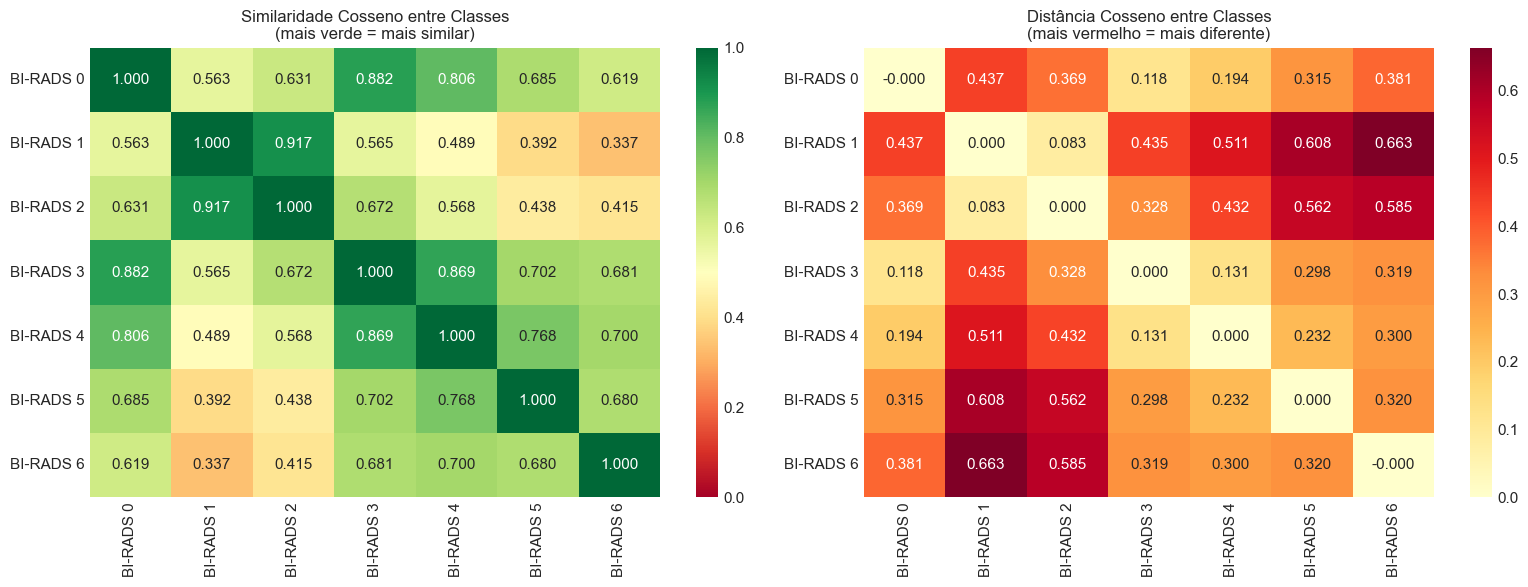


PARES MAIS SIMILARES (difíceis de separar):
  BI-RADS 1 ↔ 2: dist=0.0827 (Negativo ↔ Benigno)
  BI-RADS 0 ↔ 3: dist=0.1182 (Incompleto ↔ Provavelmente Benigno)
  BI-RADS 3 ↔ 4: dist=0.1313 (Provavelmente Benigno ↔ Suspeito)
  BI-RADS 0 ↔ 4: dist=0.1938 (Incompleto ↔ Suspeito)
  BI-RADS 4 ↔ 5: dist=0.2316 (Suspeito ↔ Altamente Sugestivo)

PARES MAIS DISTINTOS (fáceis de separar):
  BI-RADS 1 ↔ 4: dist=0.5110 (Negativo ↔ Suspeito)
  BI-RADS 2 ↔ 5: dist=0.5621 (Benigno ↔ Altamente Sugestivo)
  BI-RADS 2 ↔ 6: dist=0.5846 (Benigno ↔ Malignidade Comprovada)
  BI-RADS 1 ↔ 5: dist=0.6075 (Negativo ↔ Altamente Sugestivo)
  BI-RADS 1 ↔ 6: dist=0.6633 (Negativo ↔ Malignidade Comprovada)


In [8]:
# ============================================================
# 5a. DISTÂNCIA COSSENO ENTRE CENTROIDES DE CLASSE
# ============================================================
# Centroide = média dos vetores TF-IDF de cada classe
centroids = np.zeros((len(classes), X_tfidf.shape[1]))
for i, c in enumerate(classes):
    mask = (train[target_col] == c).values
    centroids[i] = X_tfidf[mask].mean(axis=0).A1

# Matriz de similaridade cosseno
cos_sim = cosine_similarity(centroids)
cos_dist = 1 - cos_sim  # distância = 1 - similaridade

# Heatmap de distância
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Similaridade
sns.heatmap(cos_sim, annot=True, fmt='.3f', cmap='RdYlGn',
            xticklabels=[f'BI-RADS {c}' for c in classes],
            yticklabels=[f'BI-RADS {c}' for c in classes],
            vmin=0, vmax=1, ax=axes[0])
axes[0].set_title('Similaridade Cosseno entre Classes\n(mais verde = mais similar)', fontsize=12)

# Distância
sns.heatmap(cos_dist, annot=True, fmt='.3f', cmap='YlOrRd',
            xticklabels=[f'BI-RADS {c}' for c in classes],
            yticklabels=[f'BI-RADS {c}' for c in classes],
            vmin=0, ax=axes[1])
axes[1].set_title('Distância Cosseno entre Classes\n(mais vermelho = mais diferente)', fontsize=12)

plt.tight_layout()
plt.show()

# Pares mais confusos (menor distância) e mais distintos
print('\nPARES MAIS SIMILARES (difíceis de separar):')
pair_dists = []
for i, j in combinations(range(len(classes)), 2):
    pair_dists.append((classes[i], classes[j], cos_dist[i, j]))
pair_dists.sort(key=lambda x: x[2])

for c1, c2, d in pair_dists[:5]:
    print(f'  BI-RADS {c1} ↔ {c2}: dist={d:.4f} ({BIRADS_LABELS[c1]} ↔ {BIRADS_LABELS[c2]})')

print('\nPARES MAIS DISTINTOS (fáceis de separar):')
for c1, c2, d in pair_dists[-5:]:
    print(f'  BI-RADS {c1} ↔ {c2}: dist={d:.4f} ({BIRADS_LABELS[c1]} ↔ {BIRADS_LABELS[c2]})')

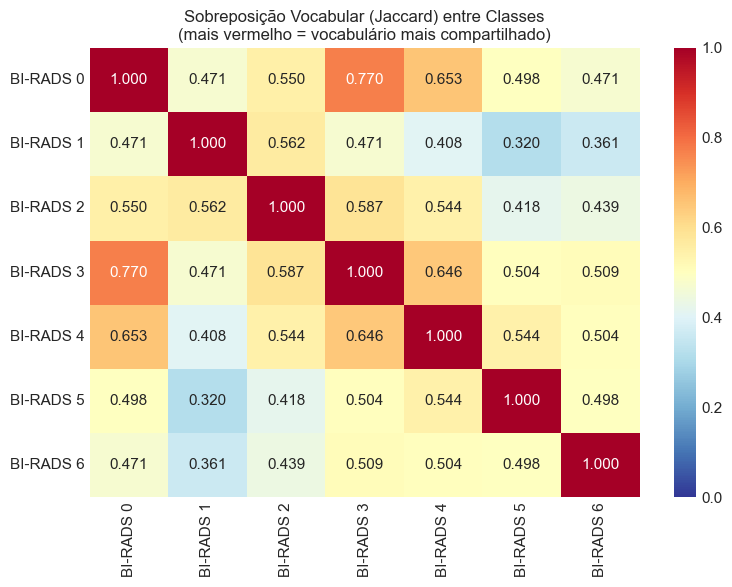


TERMOS EXCLUSIVOS (aparecem no top-200 de UMA classe apenas):
  BI-RADS 0 (Incompleto): ['cm as', 'contornos parcialmente', 'devido', 'devido sobreposição', 'esquerda calcificações', 'individualizados', 'individualizados devido', 'nódulo de', 'parcialmente individualizados', 'projeção', 'tecidual localizado']
  BI-RADS 1 (Negativo): ['adiposas não', 'alteração observada', 'apenas', 'apenas laudo', 'após estudo', 'arquitetural podendo', 'axilares de', 'caracterizada', 'clínica reavaliação', 'como', 'comparativa primeira', 'comparativa primeiro', 'compressão seletiva', 'data apenas', 'de alteração']
  BI-RADS 2 (Benigno): ['agrupadas linfonodo', 'algumas vasculares', 'alteração da', 'anterior', 'arquitetura', 'arquitetura habitual', 'bilaterais', 'cirúrgica', 'cirúrgica calcificações', 'da arquitetura', 'de manipulação', 'decorrente', 'decorrente de', 'direita as', 'esparsas algumas']
  BI-RADS 3 (Provavelmente Benigno): ['calcificações puntiformes', 'cm estável', 'com margens', 'contro

In [9]:
# ============================================================
# 5b. SOBREPOSIÇÃO VOCABULAR (Jaccard) ENTRE CLASSES
# ============================================================
def get_class_vocab(df, text_col, target_col, top_n=200):
    """Retorna set dos top_n termos de cada classe."""
    vocabs = {}
    for c in sorted(df[target_col].unique()):
        texts = df[df[target_col] == c][text_col]
        vec = CountVectorizer(ngram_range=(1,2), min_df=2, max_features=top_n)
        vec.fit(texts)
        vocabs[c] = set(vec.get_feature_names_out())
    return vocabs

vocabs = get_class_vocab(train, text_col, target_col, top_n=200)

# Jaccard similarity entre pares
jaccard_matrix = np.zeros((len(classes), len(classes)))
for i, c1 in enumerate(classes):
    for j, c2 in enumerate(classes):
        if i == j:
            jaccard_matrix[i, j] = 1.0
        else:
            intersection = len(vocabs[c1] & vocabs[c2])
            union = len(vocabs[c1] | vocabs[c2])
            jaccard_matrix[i, j] = intersection / union if union > 0 else 0

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(jaccard_matrix, annot=True, fmt='.3f', cmap='RdYlBu_r',
            xticklabels=[f'BI-RADS {c}' for c in classes],
            yticklabels=[f'BI-RADS {c}' for c in classes],
            vmin=0, vmax=1, ax=ax)
ax.set_title('Sobreposição Vocabular (Jaccard) entre Classes\n(mais vermelho = vocabulário mais compartilhado)', fontsize=12)
plt.tight_layout()
plt.show()

# Termos EXCLUSIVOS de cada classe
print('\nTERMOS EXCLUSIVOS (aparecem no top-200 de UMA classe apenas):')
all_vocabs = set().union(*vocabs.values())
for c in classes:
    other_vocabs = set().union(*[v for k, v in vocabs.items() if k != c])
    exclusive = vocabs[c] - other_vocabs
    label = BIRADS_LABELS.get(c, str(c))
    if exclusive:
        print(f'  BI-RADS {c} ({label}): {sorted(exclusive)[:15]}')
    else:
        print(f'  BI-RADS {c} ({label}): nenhum termo exclusivo no top-200')

In [10]:
# ============================================================
# 5c. SILHOUETTE SCORE + MÉTRICAS GLOBAIS
# ============================================================
# Reduzir dimensionalidade para calcular silhouette eficientemente
svd = TruncatedSVD(n_components=50, random_state=SEED)
X_reduced = svd.fit_transform(X_tfidf)

# Silhouette score global
sil_score = silhouette_score(X_reduced, y, metric='cosine', sample_size=min(5000, len(y)))

# Silhouette por classe
from sklearn.metrics import silhouette_samples
sil_samples = silhouette_samples(X_reduced, y, metric='cosine')

print('MÉTRICAS DE SEPARABILIDADE DAS CLASSES')
print('=' * 60)
print(f'\n  Silhouette Score Global: {sil_score:.4f}')
print(f'  (0 = sobreposição total | 1 = clusters perfeitamente separados)')
print(f'  Variância explicada (SVD 50d): {svd.explained_variance_ratio_.sum():.1%}')

print(f'\n  Silhouette por Classe:')
for c in classes:
    mask = y == c
    sil_c = sil_samples[mask].mean()
    count = mask.sum()
    label = BIRADS_LABELS.get(c, str(c))
    bar = '█' * int(max(0, sil_c) * 40)
    print(f'    BI-RADS {c} ({label:25s}): {sil_c:+.4f} (n={count:4d}) {bar}')

# Média distância intra-classe vs inter-classe
print(f'\n  Distância cosseno média inter-classes: {cos_dist[np.triu_indices(len(classes), k=1)].mean():.4f}')
print(f'  Distância cosseno mínima entre classes: {cos_dist[np.triu_indices(len(classes), k=1)].min():.4f}')

print(f'\n  📊 BASELINE DE HETEROGENEIDADE (antes de pré-processamento):')
print(f'     → Use estas métricas para comparar COM pré-processamento!')

MÉTRICAS DE SEPARABILIDADE DAS CLASSES

  Silhouette Score Global: -0.0576
  (0 = sobreposição total | 1 = clusters perfeitamente separados)
  Variância explicada (SVD 50d): 65.0%

  Silhouette por Classe:
    BI-RADS 0 (Incompleto               ): -0.0373 (n= 610) 
    BI-RADS 1 (Negativo                 ): +0.1612 (n= 693) ██████
    BI-RADS 2 (Benigno                  ): -0.0622 (n=15968) 
    BI-RADS 3 (Provavelmente Benigno    ): -0.0893 (n= 713) 
    BI-RADS 4 (Suspeito                 ): -0.0635 (n= 214) 
    BI-RADS 5 (Altamente Sugestivo      ): +0.1135 (n=  29) ████
    BI-RADS 6 (Malignidade Comprovada   ): -0.0360 (n=  45) 

  Distância cosseno média inter-classes: 0.3629
  Distância cosseno mínima entre classes: 0.0827

  📊 BASELINE DE HETEROGENEIDADE (antes de pré-processamento):
     → Use estas métricas para comparar COM pré-processamento!


## 6. Visualização t-SNE / PCA

Projeção 2D dos laudos para visualizar a separação entre classes.

Rodando t-SNE com 2000 amostras...


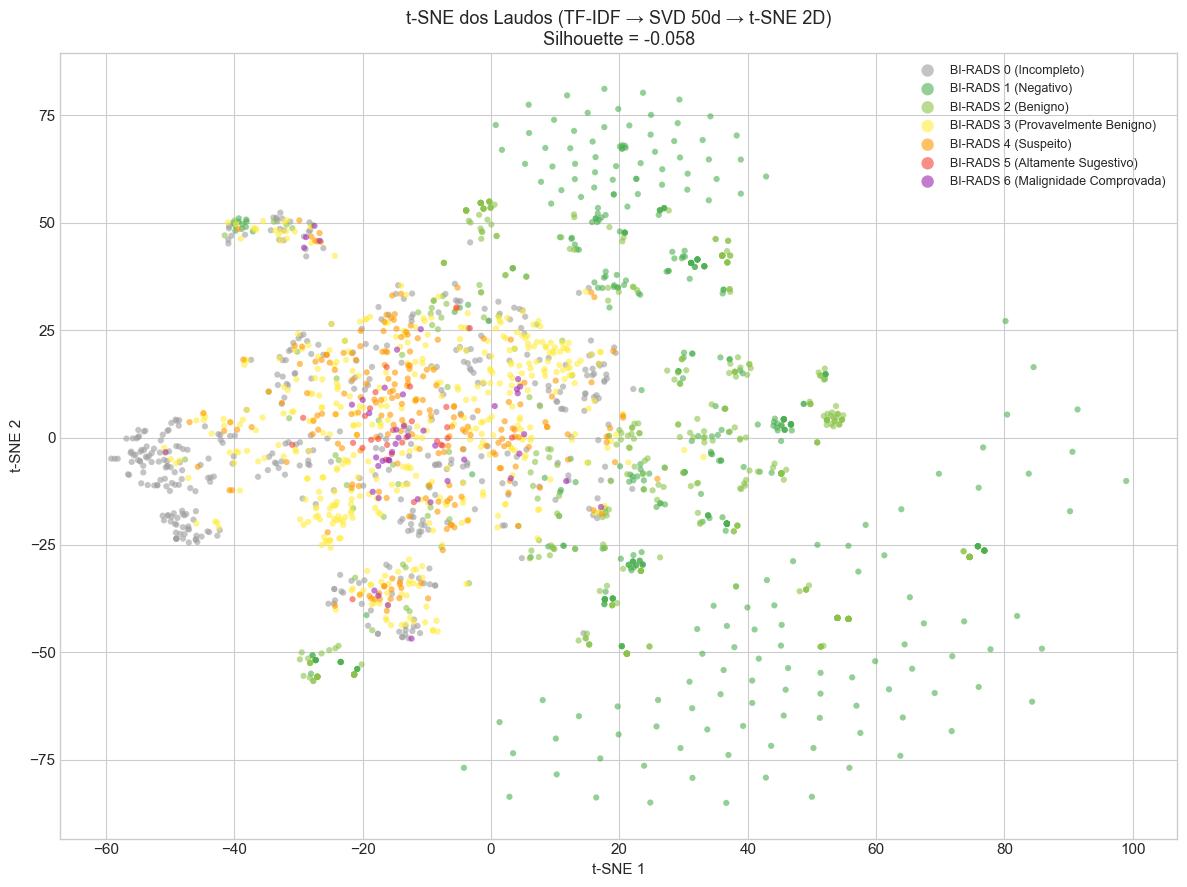

In [12]:
# ============================================================
# 6. t-SNE 2D
# ============================================================
# Usar amostra para t-SNE (é lento com muitos pontos)
MAX_SAMPLES = 3000
if len(train) > MAX_SAMPLES:
    # Amostra estratificada
    sample_idx = train.groupby(target_col).apply(
        lambda x: x.sample(min(len(x), MAX_SAMPLES // len(classes)), random_state=SEED)
    ).index.get_level_values(1)
    X_sample = X_reduced[sample_idx]
    y_sample = y[sample_idx]
else:
    X_sample = X_reduced
    y_sample = y

print(f'Rodando t-SNE com {len(y_sample)} amostras...')
tsne = TSNE(n_components=2, random_state=SEED, perplexity=30, max_iter=1000)
X_tsne = tsne.fit_transform(X_sample)

fig, ax = plt.subplots(figsize=(12, 9))
for c in classes:
    mask = y_sample == c
    label = f'BI-RADS {c} ({BIRADS_LABELS.get(c, "")})'
    ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1], 
               c=BIRADS_COLORS.get(c, '#333'), label=label,
               alpha=0.6, s=20, edgecolors='none')

ax.legend(fontsize=9, markerscale=2, loc='best')
ax.set_title(f't-SNE dos Laudos (TF-IDF → SVD 50d → t-SNE 2D)\nSilhouette = {sil_score:.3f}', fontsize=13)
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
plt.tight_layout()
plt.show()

## 7. Análise de Confusão Vocabular

Quais classes compartilham mais vocabulário? Isso indica onde o modelo vai errar mais.

In [13]:
# ============================================================
# 7a. TERMOS COMPARTILHADOS ENTRE PARES DE CLASSES PRÓXIMAS
# ============================================================
print('TERMOS COMPARTILHADOS ENTRE CLASSES MAIS CONFUSAS')
print('=' * 80)
print('(top termos que aparecem muito nos DOIS e dificultam a separação)\n')

# Pegar os 5 pares mais similares
for c1, c2, d in pair_dists[:5]:
    # Termos frequentes em ambas
    mask1 = (train[target_col] == c1).values
    mask2 = (train[target_col] == c2).values
    
    mean1 = X_tfidf[mask1].mean(axis=0).A1
    mean2 = X_tfidf[mask2].mean(axis=0).A1
    
    # Termos com alto TF-IDF em AMBAS
    shared_importance = np.minimum(mean1, mean2)
    top_shared = shared_importance.argsort()[::-1][:10]
    
    # Termos que DIFERENCIAM (alto em uma, baixo na outra)
    diff = mean1 - mean2
    top_c1 = diff.argsort()[::-1][:5]  # mais fortes em c1
    top_c2 = diff.argsort()[:5]        # mais fortes em c2
    
    l1 = BIRADS_LABELS.get(c1, str(c1))
    l2 = BIRADS_LABELS.get(c2, str(c2))
    print(f'\n  BI-RADS {c1} ({l1}) ↔ BI-RADS {c2} ({l2}) | dist={d:.4f}')
    
    print(f'    Compartilhados (confundem o modelo):')
    for idx in top_shared:
        print(f'      "{feature_names[idx]}" → c{c1}={mean1[idx]:.4f} | c{c2}={mean2[idx]:.4f}')
    
    print(f'    Diferenciam → BI-RADS {c1}:')
    for idx in top_c1:
        print(f'      "{feature_names[idx]}" → c{c1}={mean1[idx]:.4f} vs c{c2}={mean2[idx]:.4f}')
    
    print(f'    Diferenciam → BI-RADS {c2}:')
    for idx in top_c2:
        print(f'      "{feature_names[idx]}" → c{c1}={mean1[idx]:.4f} vs c{c2}={mean2[idx]:.4f}')

TERMOS COMPARTILHADOS ENTRE CLASSES MAIS CONFUSAS
(top termos que aparecem muito nos DOIS e dificultam a separação)


  BI-RADS 1 (Negativo) ↔ BI-RADS 2 (Benigno) | dist=0.0827
    Compartilhados (confundem o modelo):
      "não" → c1=0.1998 | c2=0.1652
      "análise" → c1=0.1161 | c2=0.0853
      "análise comparativa" → c1=0.1160 | c2=0.0853
      "comparativa" → c1=0.1159 | c2=0.0853
      "se" → c1=0.0882 | c2=0.0842
      "não se" → c1=0.0878 | c2=0.0838
      "observam" → c1=0.0880 | c2=0.0835
      "se observam" → c1=0.0881 | c2=0.0835
      "alterações" → c1=0.0865 | c2=0.0829
      "significativas" → c1=0.0865 | c2=0.0827
    Diferenciam → BI-RADS 1:
      "nódulos não" → c1=0.0996 vs c2=0.0017
      "lipossubstituídas não" → c1=0.0392 vs c2=0.0008
      "não" → c1=0.1998 vs c2=0.1652
      "para análise" → c1=0.0820 vs c2=0.0493
      "comparativa mamografias" → c1=0.0818 vs c2=0.0492
    Diferenciam → BI-RADS 2:
      "calcificações benignas" → c1=0.0003 vs c2=0.0591
      "

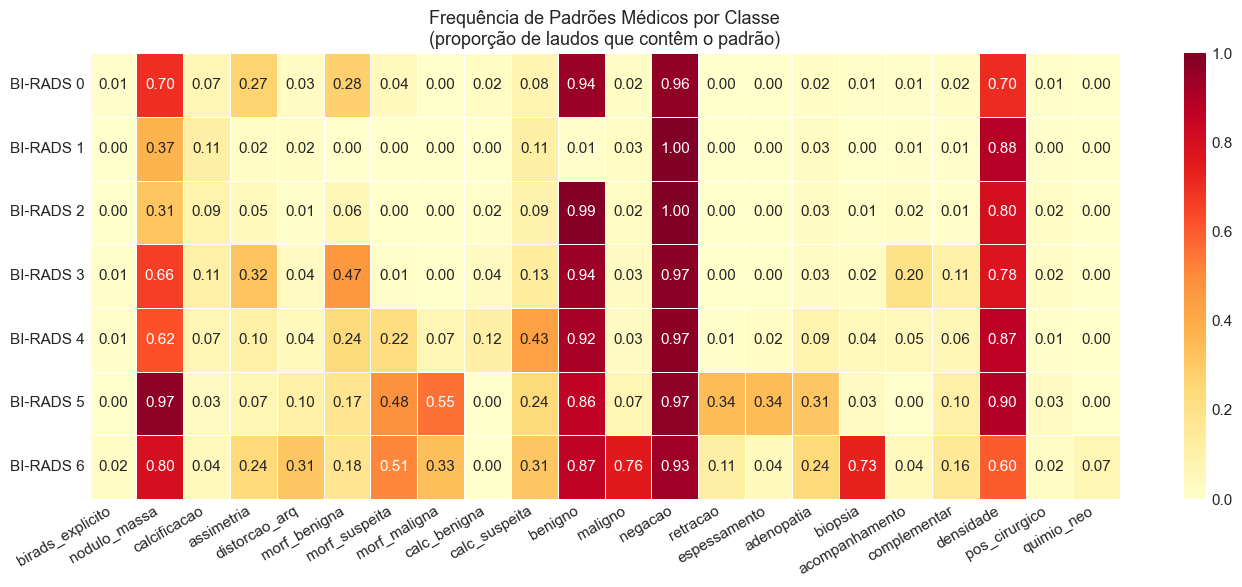


FREQUÊNCIA DE PADRÕES MÉDICOS POR CLASSE (% dos laudos):
        has_birads_explicito  has_nodulo_massa  has_calcificacao  has_assimetria  has_distorcao_arq  has_morf_benigna  has_morf_suspeita  has_morf_maligna  has_calc_benigna  has_calc_suspeita  has_benigno  has_maligno  has_negacao  has_retracao  has_espessamento  has_adenopatia  has_biopsia  has_acompanhamento  has_complementar  has_densidade  has_pos_cirurgico  has_quimio_neo
target                                                                                                                                                                                                                                                                                                                                                                                     
0                      0.007             0.700             0.069           0.267              0.030             0.275              0.039             0.002             0.025          

In [14]:
# ============================================================
# 7b. PADRÕES MÉDICOS: busca de termos-chave BI-RADS
# ============================================================
# Padrões baseados no glossário BI-RADS (birads_glossary.md)
# Separados por domínio semântico para interpretação clara
BIRADS_PATTERNS = {
    # --- Menção direta ---
    'birads_explicito': r'bi-?rads?\s*:?\s*[0-6]|categori[as]?\s*[0-6]',
    
    # --- Achados principais ---
    'nodulo_massa': r'n[oó]dulo|massa|\blesão\b|les[ãa]o nodular',
    'calcificacao': r'calcifica[çc][ãa]|microcalcifica',
    'assimetria': r'assimetr[ia]',
    'distorcao_arq': r'distor[çc][ãa]o\s*(arquitetural|do parênquima)',
    
    # --- Morfologia (massa/nódulo) ---
    'morf_benigna': r'circunscrit|bem.?definid|bem.?delimitad|contornos?\s*regulare?s|oval|ovalad|redond|arredondad',
    'morf_suspeita': r'irregular|mal.?definid|indistint|microlobulad|lobulad|imprecis',
    'morf_maligna': r'espiculad|espícula',
    
    # --- Calcificações por risco ---
    'calc_benigna': r'calc\w*\s*(vascular|cutânea|grosseir|bastão|distróf|casca)|leite de cálcio|popcorn',
    'calc_suspeita': r'(amorf|heterog[eê]n|pleom[oó]rf|linear|ramificad)\w*\s*calc|(calc\w*\s*(amorf|heterog|pleom|linear|fina))',
    
    # --- Termos de benignidade ---
    'benigno': r'benign|fibroadenom|\bcisto\b|lipoma|linfonodo intramamár',
    
    # --- Termos de malignidade ---
    'maligno': r'malign|neopl[aá]si|carcinom|c[aâ]ncer',
    
    # --- Negação / normalidade ---
    'negacao': r'\bsem\b|\bnão\b|\bneg[aá]tiv|aus[eê]n[tc]i|\bnormal\b|nada digno',
    
    # --- Features associadas (sinais secundários) ---
    'retracao': r'retra[çc][ãa]o.*(pele|cutânea|papila|mamilo)|retra[çc][ãa]o cutânea',
    'espessamento': r'espessamento.*(cutâneo|pele|trabecular|ligamento)',
    'adenopatia': r'adenopatia|linfonodomegalia|linfonodo.*(axilar|aumentad)',
    
    # --- Condutas ---
    'biopsia': r'bi[oó]psia|histol[oó]g|histopatol|citopatol|pun[çc][ãa]o|paaf|core.?biops',
    'acompanhamento': r'acompanhamento|controle|6 meses|semestral|curto prazo|seguimento',
    'complementar': r'complement|adicional|incomplet|limitad|prosseguir investiga',
    
    # --- Contexto ---
    'densidade': r'densid|densa|heterog[eê]nea.?dens|fibroglandul|adipos',
    'pos_cirurgico': r'p[oó]s.?(cir[uú]rg|operat)|pr[oó]tese|cicatri',
    'quimio_neo': r'quimioterapia|neoadjuvante|resposta terap|estadiam',
}

# Detectar padrões em cada texto
for pattern_name, pattern in BIRADS_PATTERNS.items():
    train[f'has_{pattern_name}'] = train[text_col].str.contains(pattern, case=False, regex=True).astype(int)

# Frequência de cada padrão por classe
pattern_cols = [f'has_{p}' for p in BIRADS_PATTERNS.keys()]
pattern_freq = train.groupby(target_col)[pattern_cols].mean()

# Heatmap
fig, ax = plt.subplots(figsize=(14, 6))
display_names = [p.replace('has_', '') for p in pattern_cols]
sns.heatmap(pattern_freq.values, annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=display_names,
            yticklabels=[f'BI-RADS {c}' for c in classes],
            vmin=0, vmax=1, ax=ax, linewidths=0.5)
ax.set_title('Frequência de Padrões Médicos por Classe\n(proporção de laudos que contêm o padrão)', fontsize=13)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

# Print tabela
print('\nFREQUÊNCIA DE PADRÕES MÉDICOS POR CLASSE (% dos laudos):')
print(pattern_freq.round(3).to_string())

In [15]:
# ============================================================
# 7c. MENÇÕES EXPLÍCITAS DE BI-RADS NO TEXTO
# ============================================================
def extract_birads_mention(text):
    """Extrai menção explícita de BI-RADS no texto."""
    matches = re.findall(r'bi-?rads?\s*:?\s*([0-6])', str(text).lower())
    return [int(m) for m in matches] if matches else []

train['birads_mentioned'] = train[text_col].apply(extract_birads_mention)
train['has_explicit_birads'] = train['birads_mentioned'].apply(lambda x: len(x) > 0)

print('MENÇÕES EXPLÍCITAS DE BI-RADS NOS TEXTOS')
print('=' * 60)
print(f'\nLaudos com BI-RADS explícito: {train["has_explicit_birads"].sum()} / {len(train)} ({train["has_explicit_birads"].mean():.1%})')
print()

for c in classes:
    subset = train[train[target_col] == c]
    has = subset['has_explicit_birads'].mean()
    label = BIRADS_LABELS.get(c, str(c))
    print(f'  BI-RADS {c} ({label:25s}): {has:.1%} contêm menção explícita')
    
    # Verificar concordância (BI-RADS mencionado == label)
    with_mention = subset[subset['has_explicit_birads']]
    if len(with_mention) > 0:
        concordant = with_mention['birads_mentioned'].apply(lambda x: c in x).mean()
        print(f'    → Concordância (menção == label): {concordant:.1%}')
        
        # Distribuição de menções
        all_mentions = [m for mentions in with_mention['birads_mentioned'] for m in mentions]
        mention_dist = Counter(all_mentions)
        if len(mention_dist) > 1:
            print(f'    → Menções encontradas: {dict(sorted(mention_dist.items()))}')

MENÇÕES EXPLÍCITAS DE BI-RADS NOS TEXTOS

Laudos com BI-RADS explícito: 8 / 18272 (0.0%)

  BI-RADS 0 (Incompleto               ): 0.0% contêm menção explícita
  BI-RADS 1 (Negativo                 ): 0.0% contêm menção explícita
  BI-RADS 2 (Benigno                  ): 0.0% contêm menção explícita
    → Concordância (menção == label): 20.0%
    → Menções encontradas: {0: 1, 2: 1, 3: 2, 4: 2}
  BI-RADS 3 (Provavelmente Benigno    ): 0.3% contêm menção explícita
    → Concordância (menção == label): 100.0%
  BI-RADS 4 (Suspeito                 ): 0.5% contêm menção explícita
    → Concordância (menção == label): 100.0%
  BI-RADS 5 (Altamente Sugestivo      ): 0.0% contêm menção explícita
  BI-RADS 6 (Malignidade Comprovada   ): 0.0% contêm menção explícita


## 8. Resumo e Próximos Passos

Consolidação das métricas de baseline para comparar com pré-processamento.

In [16]:
# ============================================================
# 8. RESUMO CONSOLIDADO
# ============================================================
print('=' * 70)
print('  RESUMO — BASELINE DE HETEROGENEIDADE (ANTES DE PRÉ-PROCESSAMENTO)')
print('=' * 70)

print(f'''
  📊 Dataset:
     Amostras: {len(train)}
     Classes: {len(classes)}
     Imbalance ratio: {train[target_col].value_counts().max() / train[target_col].value_counts().min():.1f}x

  📐 Separabilidade:
     Silhouette Score Global: {sil_score:.4f}
     Distância cosseno média inter-classes: {cos_dist[np.triu_indices(len(classes), k=1)].mean():.4f}
     Distância cosseno mínima: {cos_dist[np.triu_indices(len(classes), k=1)].min():.4f}
     Jaccard médio (sobreposição vocabular): {jaccard_matrix[np.triu_indices(len(classes), k=1)].mean():.4f}

  📝 Textos:
     Palavras (média): {train['word_count'].mean():.0f}
     Palavras (mediana): {train['word_count'].median():.0f}
     Laudos com BI-RADS explícito: {train['has_explicit_birads'].mean():.1%}

  🎯 Para comparar após pré-processamento, acompanhe:
     1. Silhouette Score  (↑ melhor)
     2. Distância cosseno média  (↑ melhor)
     3. Jaccard vocabular  (↓ melhor = menos sobreposição)
''')

  RESUMO — BASELINE DE HETEROGENEIDADE (ANTES DE PRÉ-PROCESSAMENTO)

  📊 Dataset:
     Amostras: 18272
     Classes: 7
     Imbalance ratio: 550.6x

  📐 Separabilidade:
     Silhouette Score Global: -0.0576
     Distância cosseno média inter-classes: 0.3629
     Distância cosseno mínima: 0.0827
     Jaccard médio (sobreposição vocabular): 0.5109

  📝 Textos:
     Palavras (média): 45
     Palavras (mediana): 40
     Laudos com BI-RADS explícito: 0.0%

  🎯 Para comparar após pré-processamento, acompanhe:
     1. Silhouette Score  (↑ melhor)
     2. Distância cosseno média  (↑ melhor)
     3. Jaccard vocabular  (↓ melhor = menos sobreposição)



In [18]:
# Exportar dados para arquivo texto (documento de análise)
import os
out_path = os.path.join(DATA_DIR, 'analysis_export.txt')
with open(out_path, 'w', encoding='utf-8') as f:
    # 1. Chi² top 10
    f.write("=== CHI2 TOP 10 POR CLASSE ===\n\n")
    for c in classes:
        label = BIRADS_LABELS.get(c, str(c))
        y_binary = (y == c).astype(int)
        sc, pv = chi2(X_tfidf, y_binary)
        top_idx = sc.argsort()[::-1][:10]
        f.write(f"BI-RADS {c} ({label}):\n")
        for idx in top_idx:
            f.write(f"  chi2={sc[idx]:8.1f}  \"{feature_names[idx]}\"\n")
        f.write("\n")
    
    # 2. Log-Odds top 8
    f.write("\n=== LOG-ODDS TOP 8 ENRIQUECIDOS ===\n\n")
    for c in classes:
        label = BIRADS_LABELS.get(c, str(c))
        f.write(f"BI-RADS {c} ({label}):\n")
        for term, score in log_odds_results[c]['enriched'][:8]:
            f.write(f"  log2OR={score:+.2f}  \"{term}\"\n")
        f.write("  Ausentes:\n")
        for term, score in log_odds_results[c]['depleted'][:5]:
            f.write(f"  log2OR={score:+.2f}  \"{term}\"\n")
        f.write("\n")
    
    # 3. Confusão vocabular top 3
    f.write("\n=== CONFUSAO VOCABULAR TOP 3 PARES ===\n\n")
    for c1, c2, d in pair_dists[:3]:
        mask1v = (train[target_col] == c1).values
        mask2v = (train[target_col] == c2).values
        m1 = X_tfidf[mask1v].mean(axis=0).A1
        m2 = X_tfidf[mask2v].mean(axis=0).A1
        shared = np.minimum(m1, m2)
        top_sh = shared.argsort()[::-1][:8]
        diff = m1 - m2
        top_d1 = diff.argsort()[::-1][:5]
        top_d2 = diff.argsort()[:5]
        f.write(f"{BIRADS_LABELS[c1]} x {BIRADS_LABELS[c2]} (dist={d:.4f}):\n")
        f.write(f"  Compartilhados:\n")
        for i in top_sh:
            f.write(f"    \"{feature_names[i]}\" -> c{c1}={m1[i]:.4f} | c{c2}={m2[i]:.4f}\n")
        f.write(f"  Mais forte em {c1}:\n")
        for i in top_d1:
            f.write(f"    \"{feature_names[i]}\" -> c{c1}={m1[i]:.4f} vs c{c2}={m2[i]:.4f}\n")
        f.write(f"  Mais forte em {c2}:\n")
        for i in top_d2:
            f.write(f"    \"{feature_names[i]}\" -> c{c1}={m1[i]:.4f} vs c{c2}={m2[i]:.4f}\n")
        f.write("\n")
    
    # 4. Pattern freq
    f.write("\n=== PATTERN FREQ POR CLASSE ===\n\n")
    f.write(pattern_freq.round(3).to_string())
    f.write("\n")

    # 5. Exemplos de laudos (1 por classe, mediana)
    f.write("\n\n=== EXEMPLOS DE LAUDOS (mediana) ===\n\n")
    for target in sorted(train[target_col].unique()):
        subset = train[train[target_col] == target]
        subset_sorted = subset.sort_values('word_count')
        ex = subset_sorted.iloc[len(subset_sorted) // 2]
        label = BIRADS_LABELS.get(target, str(target))
        f.write(f"BI-RADS {target} ({label}) - {ex['word_count']} palavras:\n")
        f.write(f"{ex[text_col][:600]}\n\n")
    
    # 6. Termos exclusivos
    f.write("\n=== TERMOS EXCLUSIVOS TOP-200 ===\n\n")
    for c in classes:
        other_v = set().union(*[v for k, v in vocabs.items() if k != c])
        excl = vocabs[c] - other_v
        label = BIRADS_LABELS.get(c, str(c))
        f.write(f"BI-RADS {c} ({label}): {sorted(excl)[:15]}\n")

print(f"Exportado para: {out_path}")

Exportado para: ../data\analysis_export.txt
